# DATA LOADING

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# DATA INFORMATION

In [41]:
df=pd.read_csv(r"C:\Users\shubh\Downloads\archive\bodyfat.csv")
df

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1.0736,11.0,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
248,1.0236,33.6,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
249,1.0328,29.3,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
250,1.0399,26.0,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8


In [42]:
df.shape

(252, 15)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [44]:
df.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [45]:
df.min()

Density      0.995
BodyFat      0.000
Age         22.000
Weight     118.500
Height      29.500
Neck        31.100
Chest       79.300
Abdomen     69.400
Hip         85.000
Thigh       47.200
Knee        33.000
Ankle       19.100
Biceps      24.800
Forearm     21.000
Wrist       15.800
dtype: float64

In [46]:
df.max()

Density      1.1089
BodyFat     47.5000
Age         81.0000
Weight     363.1500
Height      77.7500
Neck        51.2000
Chest      136.2000
Abdomen    148.1000
Hip        147.7000
Thigh       87.3000
Knee        49.1000
Ankle       33.9000
Biceps      45.0000
Forearm     34.9000
Wrist       21.4000
dtype: float64

In [47]:
df.count()

Density    252
BodyFat    252
Age        252
Weight     252
Height     252
Neck       252
Chest      252
Abdomen    252
Hip        252
Thigh      252
Knee       252
Ankle      252
Biceps     252
Forearm    252
Wrist      252
dtype: int64

In [48]:
df.isnull().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

# DATA CLEANING

In [49]:
df.drop(['Density'], axis=1, inplace=True)

In [50]:
df.isnull().sum()

BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.shape

(252, 14)

# DATA VISUALIZING

<Axes: xlabel='BodyFat'>

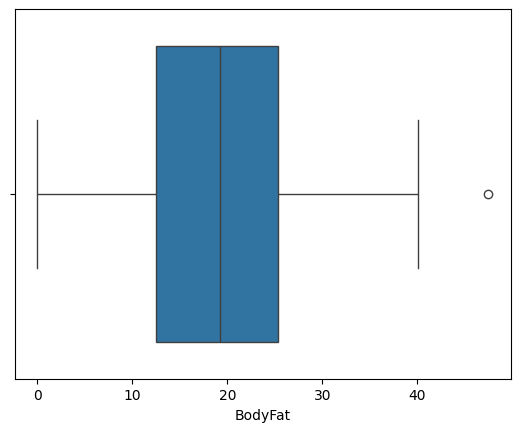

In [53]:
sns.boxplot(x="BodyFat",data=df)

<Axes: xlabel='Age'>

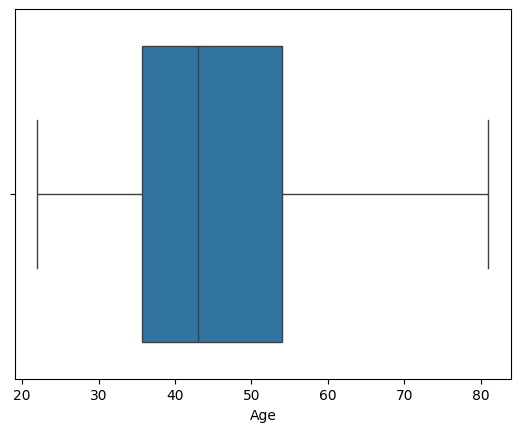

In [54]:
sns.boxplot(x="Age",data=df)

<Axes: xlabel='Weight'>

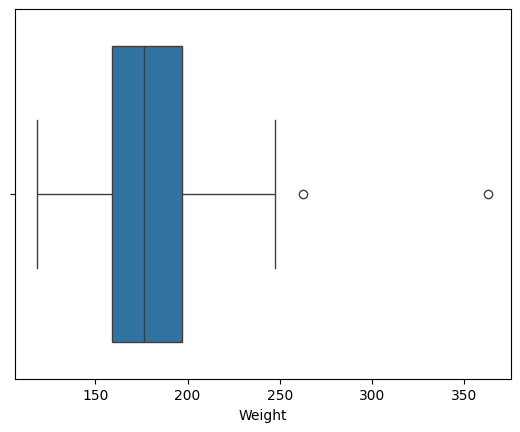

In [55]:
sns.boxplot(x="Weight",data=df)

<Axes: xlabel='Height'>

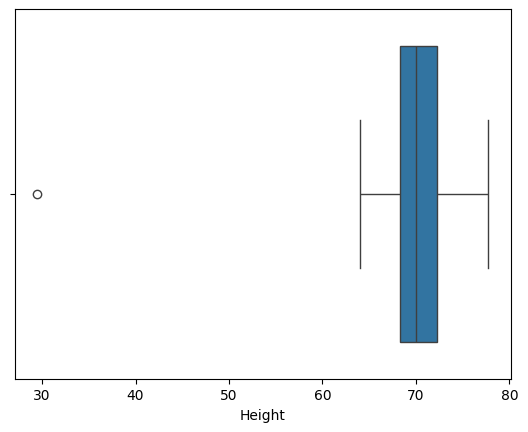

In [56]:
sns.boxplot(x="Height",data=df)

<Axes: xlabel='Neck'>

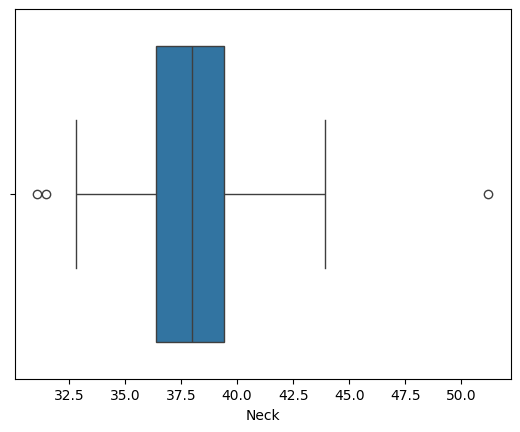

In [57]:
sns.boxplot(x="Neck",data=df)

<Axes: xlabel='Chest'>

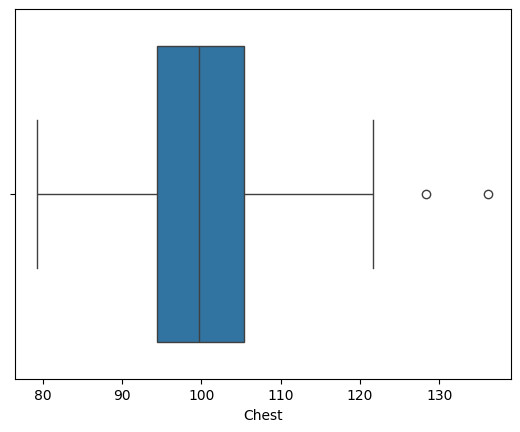

In [58]:
sns.boxplot(x="Chest",data=df)

<Axes: xlabel='Abdomen'>

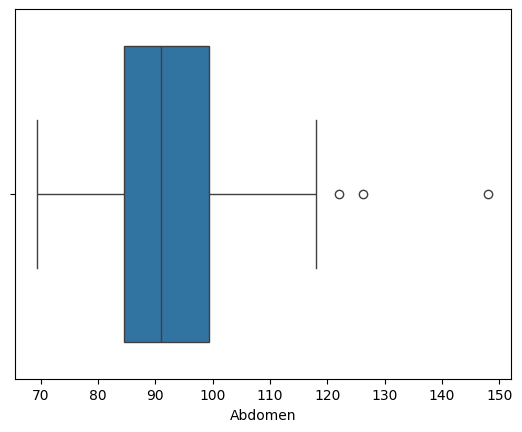

In [59]:
sns.boxplot(x="Abdomen",data=df)

<Axes: xlabel='Hip'>

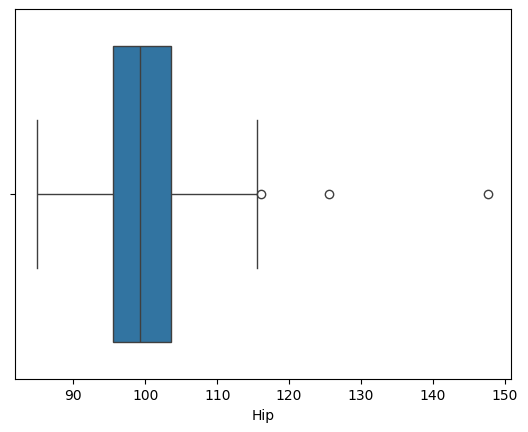

In [60]:
sns.boxplot(x="Hip",data=df)

<Axes: xlabel='Thigh'>

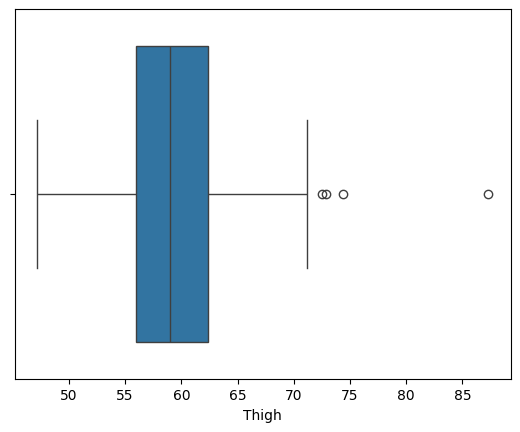

In [61]:
sns.boxplot(x="Thigh",data=df)

<Axes: xlabel='Knee'>

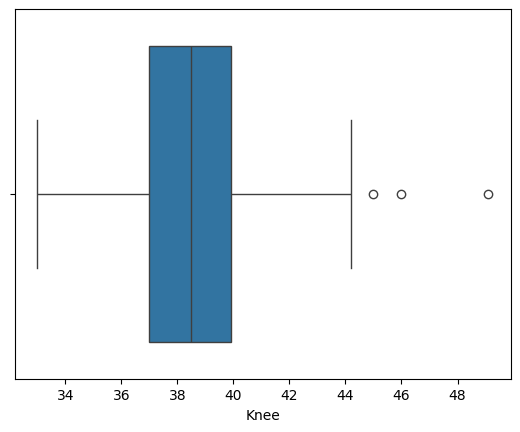

In [62]:
sns.boxplot(x="Knee",data=df)

<Axes: xlabel='Ankle'>

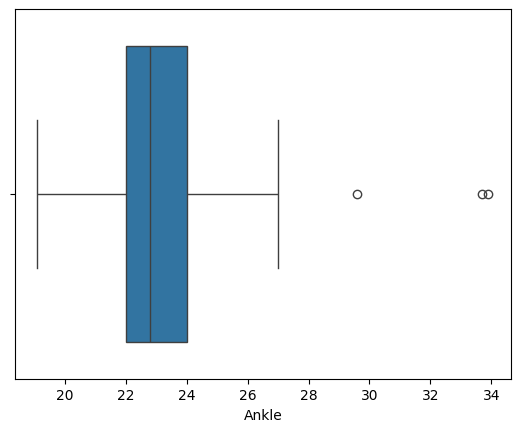

In [63]:
sns.boxplot(x="Ankle",data=df)

<Axes: xlabel='Biceps'>

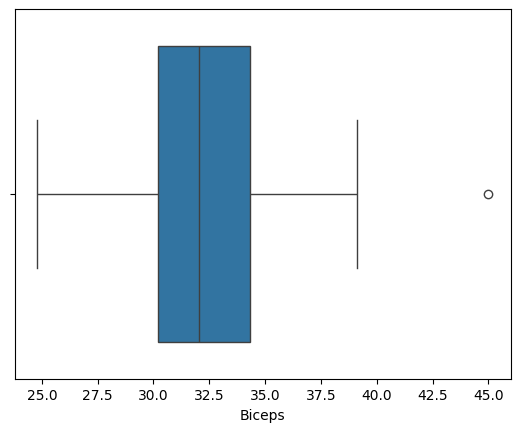

In [64]:
sns.boxplot(x="Biceps",data=df)

<Axes: xlabel='Forearm'>

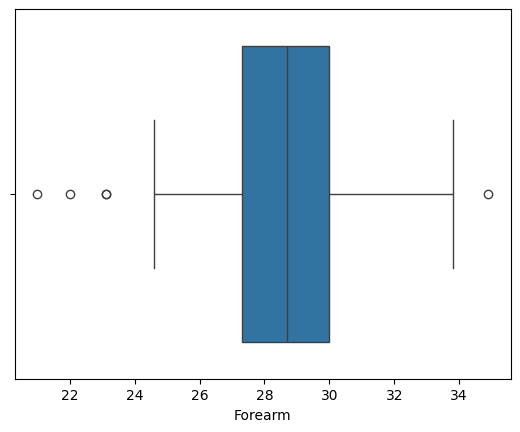

In [65]:
sns.boxplot(x="Forearm",data=df)

<Axes: xlabel='Wrist'>

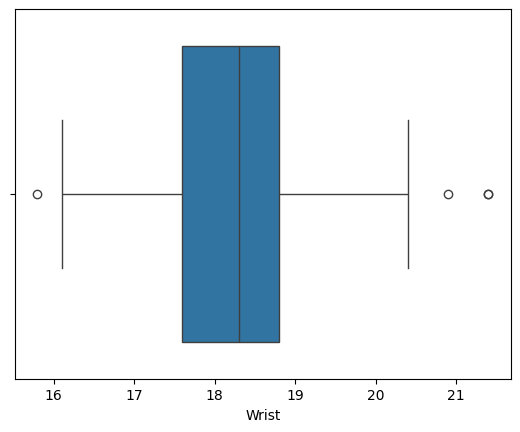

In [66]:
sns.boxplot(x="Wrist",data=df)

# TRAIN 'N' TEST SPLIT

In [67]:
df.head()

,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [68]:
df.loc["Age":"Wrist"]

,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist


In [69]:
X = df[['Age','Weight','Height','Neck','Chest','Abdomen','Hip','Thigh','Knee','Ankle','Biceps','Forearm','Wrist']]
Y = df["BodyFat"]=(df["BodyFat"]).astype(int)
Y = df["BodyFat"]
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

# Logistic regression

In [70]:
LR=LinearRegression()
LR.fit(X_train,y_train)
y_pred_lr =LR.predict(X_test)
score=r2_score(y_test,y_pred)
score

-0.5035142631105127

# ======DT

In [71]:
DT=DecisionTreeRegressor()
DT.fit(X_train,y_train)
y_pred_dt =DT.predict(X_test)
score=r2_score(y_test,y_pred)
score

-0.5035142631105127

# ======RANDOM FOREST

In [72]:
RF=RandomForestRegressor()
RF.fit(X_train,y_train)
y_pred_rf =RF.predict(X_test)
score=r2_score(y_test,y_pred)
score

-0.5035142631105127

# ====== SVM 

In [73]:
SVM=SVR(kernel='rbf')
SVM.fit(X_train,y_train)
y_pred_svr =SVM.predict(X_test)
score=r2_score(y_test,y_pred)
score

-0.5035142631105127

# ====== KNN

In [74]:
KNN=KNeighborsRegressor()
KNN.fit(X_train,y_train)
y_pred_knn =KNN.predict(X_test)
score=r2_score(y_test,y_pred)
score

-0.5035142631105127

# MODEL BUILDING

# MODEL TEST 

In [75]:
df

,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,11,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
248,33,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
249,29,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
250,26,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8


In [76]:
#RADHIKA
print( LR.predict([[21, 110, 66, 33.02, 93.98, 71.12, 96.51, 50.8, 35.56, 22.86, 22.86, 22.86, 15.24]]) )
print( DT.predict([[21, 110, 66, 33.02, 93.98, 71.12, 96.51, 50.8, 35.56, 22.86, 22.86, 22.86, 15.24]]) )
print( RF.predict([[21, 110, 66, 33.02, 93.98, 71.12, 96.51, 50.8, 35.56, 22.86, 22.86, 22.86, 15.24]]) )
print( SVM.predict([[21, 110, 66, 33.02, 93.98, 71.12, 96.51, 50.8, 35.56, 22.86, 22.86, 22.86, 15.24]]) )
print( KNN.predict([[21, 110, 66, 33.02, 93.98, 71.12, 96.51, 50.8, 35.56, 22.86, 22.86, 22.86, 15.24]]) )

[3.06905742]
[0.]
[5.99]
[11.39057069]
[7.2]


C:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
C:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:27

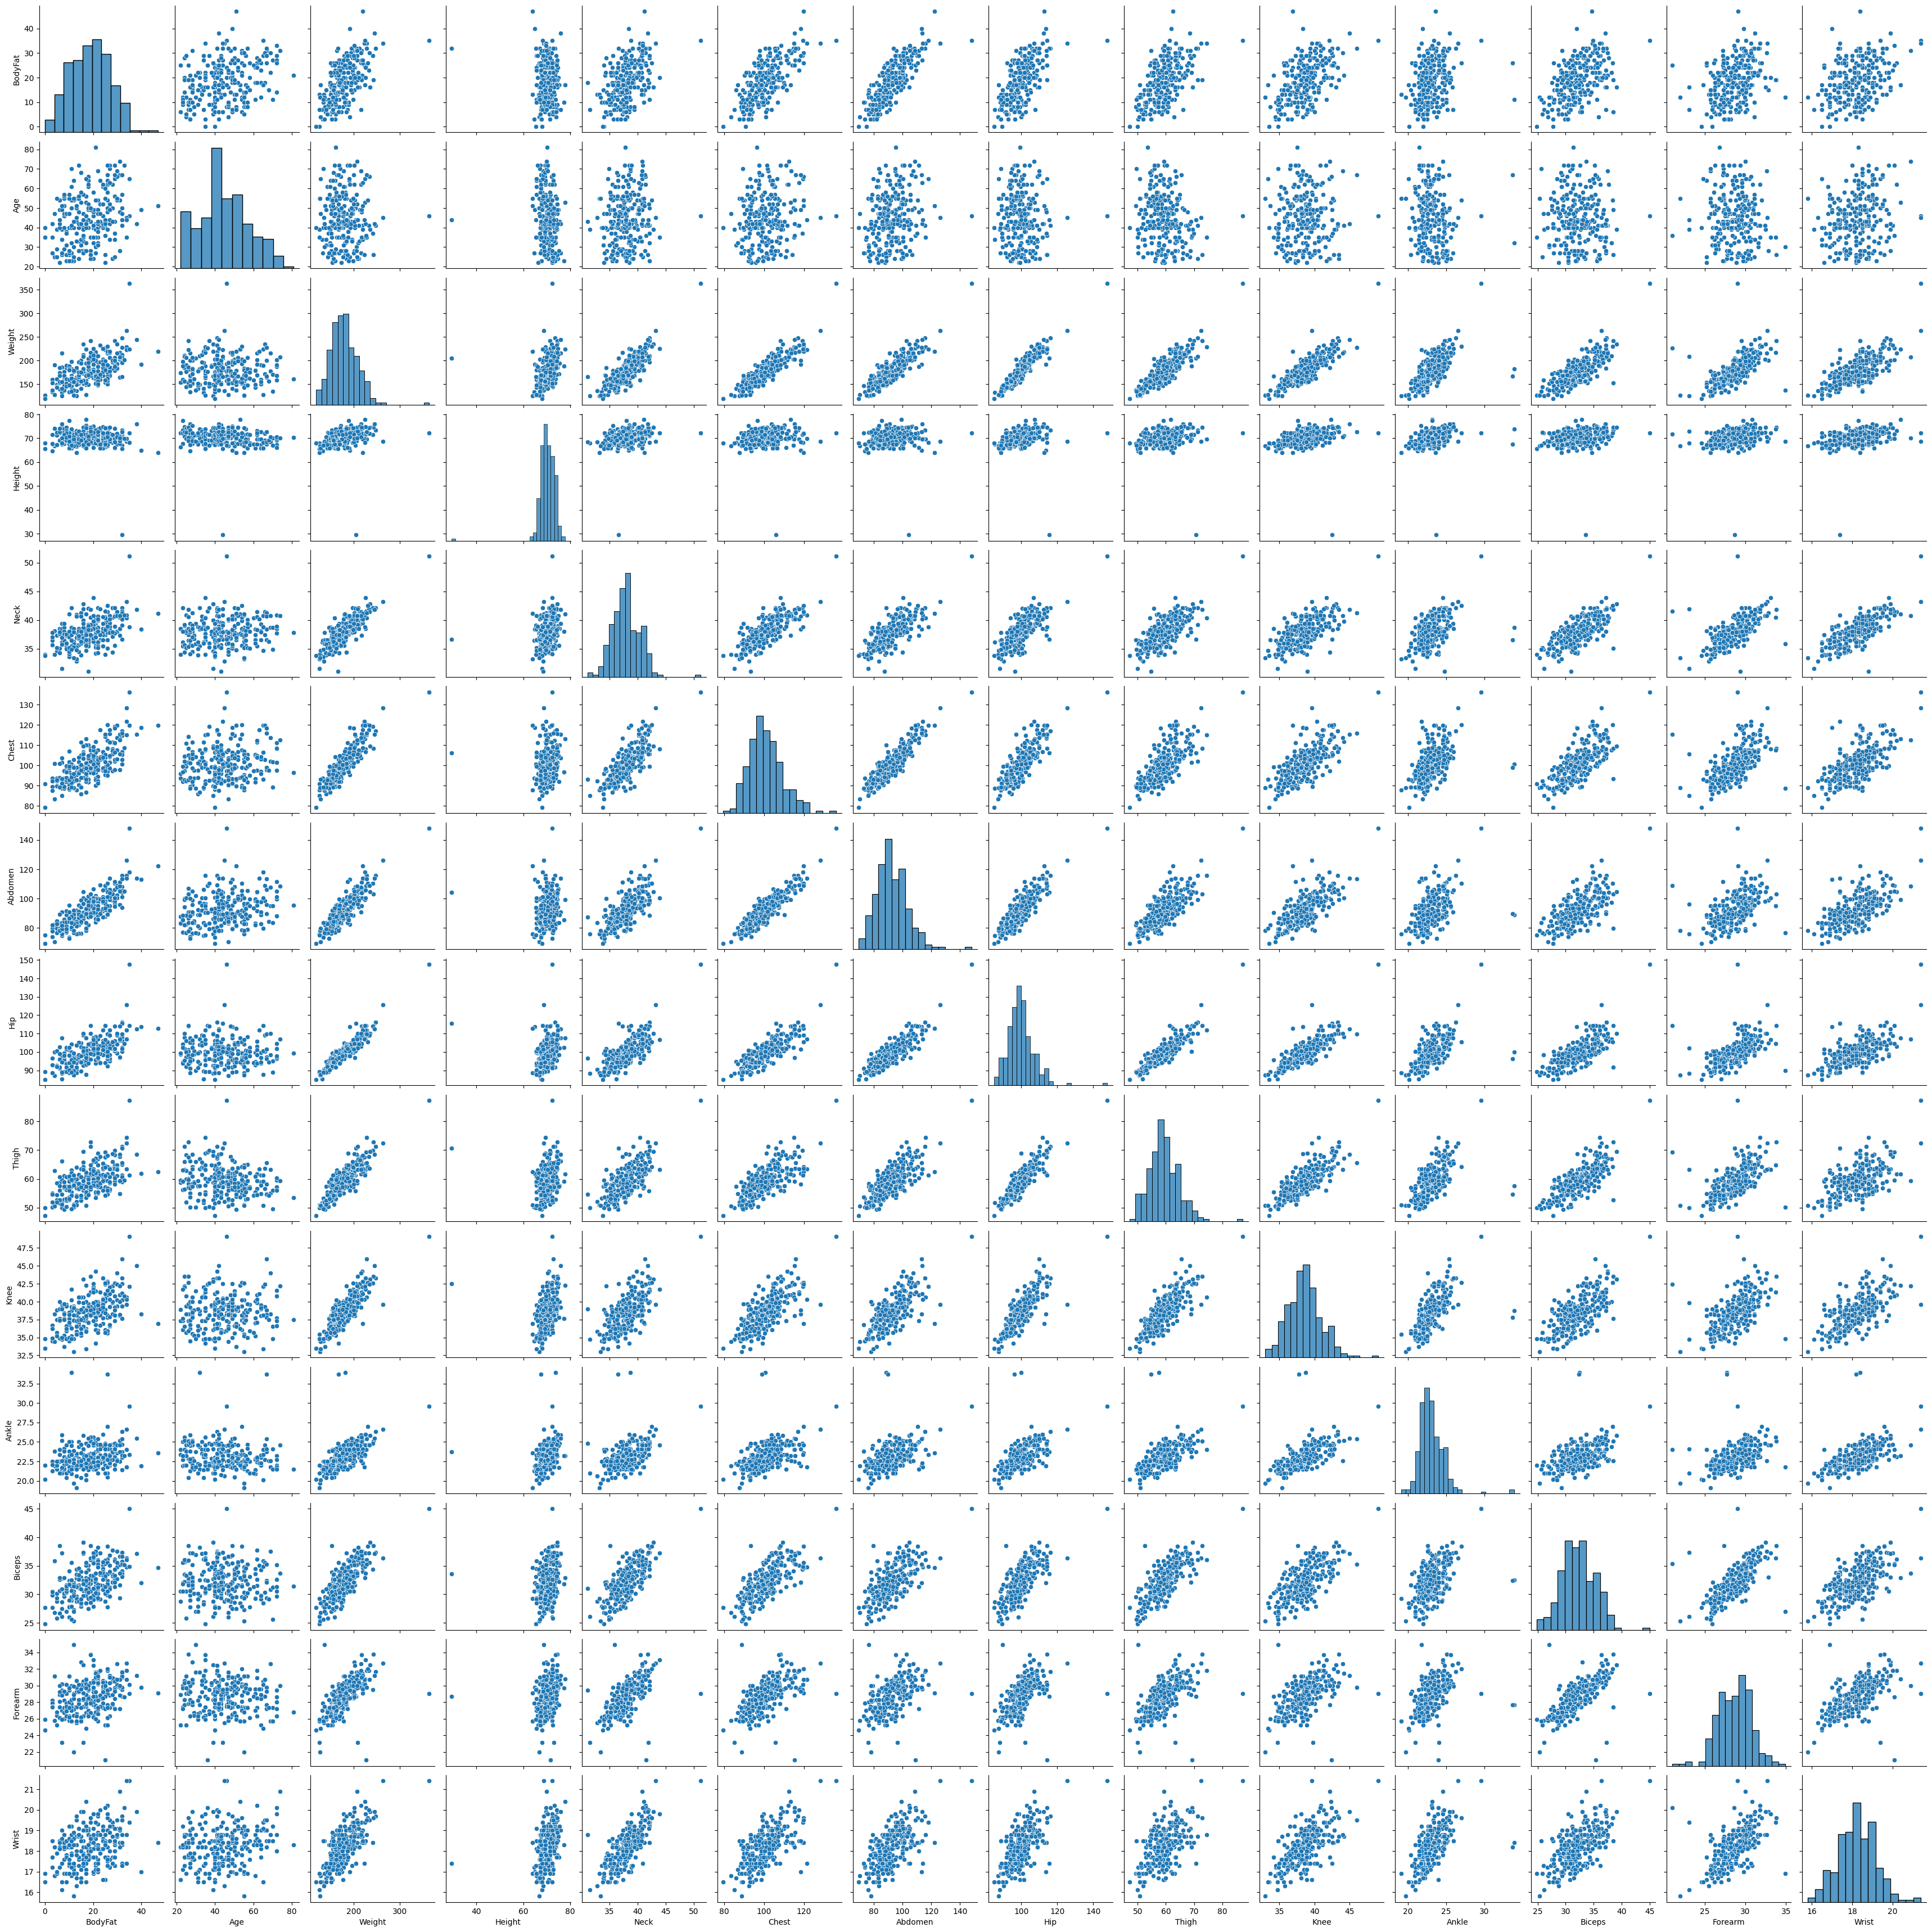

In [77]:
sns.pairplot(df)

In [78]:
results = []

models = [
    ("Linear Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("SVR", y_pred_svr),
    ("KNN Regressor", y_pred_knn),
]

for name, y_pred in models:
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "MSE": mse
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="R2", ascending=False)

comparison_df

,Model,R2,MAE,MSE
0,Linear Regression,0.783271,3.538047,18.326372
2,Random Forest,0.719777,3.927255,23.695378
4,KNN Regressor,0.609638,4.768627,33.008627
1,Decision Tree,0.575885,4.921569,35.862745
3,SVR,0.404413,5.919817,50.362218
